# Bonus: The sinc Function — Normalized vs. Unnormalized

## EE 451: Communications Systems — Lecture 3 Supplement

Two definitions of the sinc function appear in engineering and mathematics textbooks. They differ by a factor of $\pi$ in the argument, and using the wrong one will give incorrect zero locations, bandwidths, and Fourier transform results.

This notebook explains both definitions, shows why this course (and Haykin & Moher) uses the **normalized** definition, and demonstrates the practical consequences.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

print("Setup complete!")

Setup complete!


## The Two Definitions

### Normalized sinc (Haykin Eq. 2.9, used in this course)

$$\text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}$$

- Zeros at $x = \pm 1, \pm 2, \pm 3, \ldots$ (every nonzero integer)
- $\text{sinc}(0) = 1$
- $\int_{-\infty}^{\infty} \text{sinc}(x)\, dx = 1$ (unit area — hence "normalized")
- Used by: Haykin & Moher, Proakis & Salehi, most DSP textbooks, NumPy (`np.sinc`), MATLAB (`sinc`)

### Unnormalized sinc

$$\text{sinc}_{\text{unnorm}}(x) = \frac{\sin(x)}{x}$$

- Zeros at $x = \pm \pi, \pm 2\pi, \pm 3\pi, \ldots$ (every nonzero multiple of $\pi$)
- $\text{sinc}_{\text{unnorm}}(0) = 1$
- $\int_{-\infty}^{\infty} \frac{\sin(x)}{x}\, dx = \pi$ (not unit area)
- Used by: some math textbooks, some older physics references

### The relationship

$$\text{sinc}(x) = \text{sinc}_{\text{unnorm}}(\pi x)$$

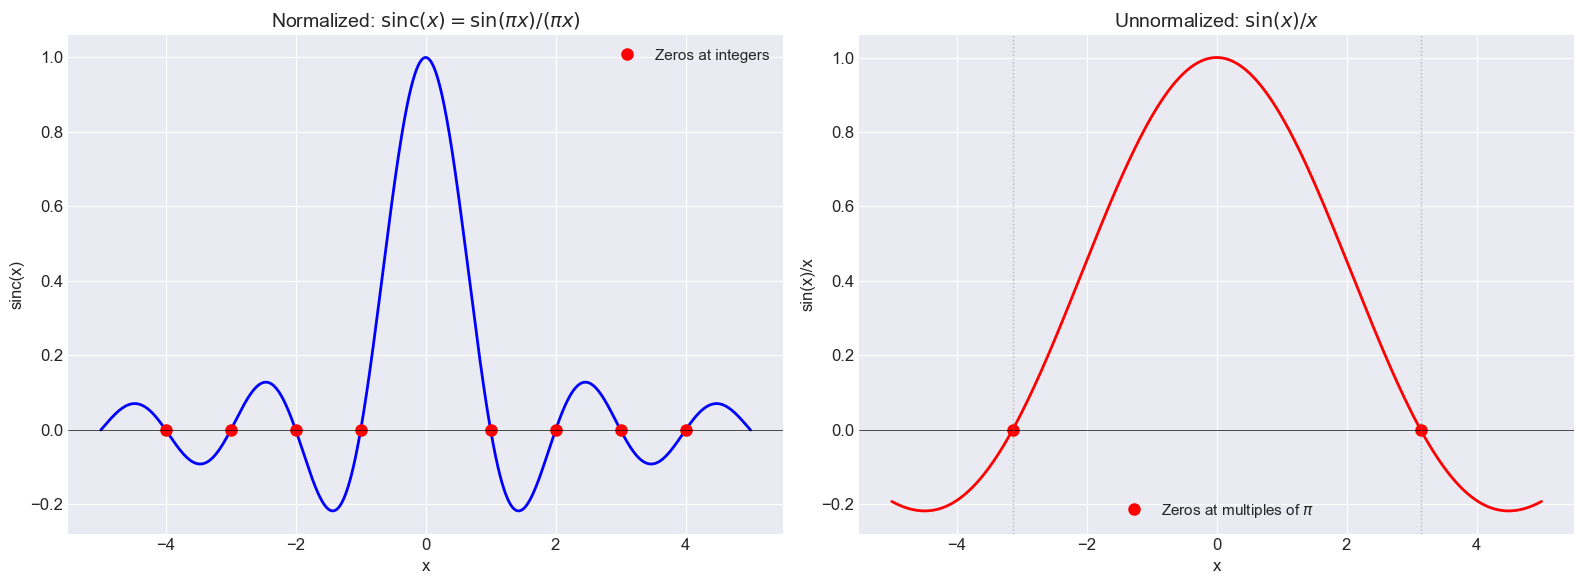

Both functions equal 1 at the origin and decay as 1/x.
Normalized zeros:   x = ±1, ±2, ±3, ...
Unnormalized zeros: x = ±π, ±2π, ±3π, ...  (≈ ±3.142, ±6.283, ...)


In [2]:
# Define both sinc functions
x = np.linspace(-5, 5, 1000)

# Normalized: sin(pi*x) / (pi*x)  — this is what np.sinc computes
sinc_norm = np.sinc(x)

# Unnormalized: sin(x) / x
sinc_unnorm = np.where(x == 0, 1.0, np.sin(x) / x)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Normalized sinc
ax = axes[0]
ax.plot(x, sinc_norm, 'b-', linewidth=2)
ax.set_title(r'Normalized: $\mathrm{sinc}(x) = \sin(\pi x)/(\pi x)$', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('sinc(x)')
# Mark zeros at integers
zeros_norm = np.arange(-4, 5)
zeros_norm = zeros_norm[zeros_norm != 0]
ax.plot(zeros_norm, np.zeros_like(zeros_norm), 'ro', markersize=8, label='Zeros at integers')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.legend(fontsize=11)

# Unnormalized sinc
ax = axes[1]
ax.plot(x, sinc_unnorm, 'r-', linewidth=2)
ax.set_title(r'Unnormalized: $\sin(x)/x$', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('sin(x)/x')
# Mark zeros at multiples of pi
zeros_unnorm = np.array([-4*np.pi, -3*np.pi, -2*np.pi, -np.pi, np.pi, 2*np.pi, 3*np.pi, 4*np.pi])
zeros_in_range = zeros_unnorm[np.abs(zeros_unnorm) <= 5]
ax.plot(zeros_in_range, np.zeros_like(zeros_in_range), 'ro', markersize=8, 
        label=r'Zeros at multiples of $\pi$')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=np.pi, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(x=-np.pi, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Both functions equal 1 at the origin and decay as 1/x.")
print(f"Normalized zeros:   x = ±1, ±2, ±3, ...")
print(f"Unnormalized zeros: x = ±π, ±2π, ±3π, ...  (≈ ±{np.pi:.3f}, ±{2*np.pi:.3f}, ...)")

## Why the Normalized Definition?

The normalized sinc makes Fourier transform pairs come out clean. Consider the rectangular pulse:

$$x(t) = A \cdot \text{rect}(t/T)$$

Its Fourier transform is:

$$X(f) = AT \cdot \text{sinc}(fT) = AT \cdot \frac{\sin(\pi f T)}{\pi f T}$$

The first zero occurs when the argument of sinc equals $\pm 1$:

$$fT = \pm 1 \quad \Longrightarrow \quad f = \pm \frac{1}{T}$$

This gives us the clean result: **the first null is at $f = 1/T$**, and the null-to-null bandwidth is $2/T$.

### What goes wrong with the unnormalized definition?

If we mistakenly write:

$$X(f) = AT \cdot \frac{\sin(\pi f T)}{\pi f T}$$

but then interpret "sinc" as $\sin(x)/x$ and write $\text{sinc}(\pi fT)$, the formula still works — but the zero location analysis changes. The zero of $\sin(x)/x$ is at $x = \pi$, so we'd need $\pi fT = \pi$, giving $f = 1/T$. You get the same answer, but only if you remember to put $\pi$ in the argument every time.

The normalized convention absorbs the $\pi$ into the function definition, so the argument is simply $fT$ and zeros occur at clean integer values.

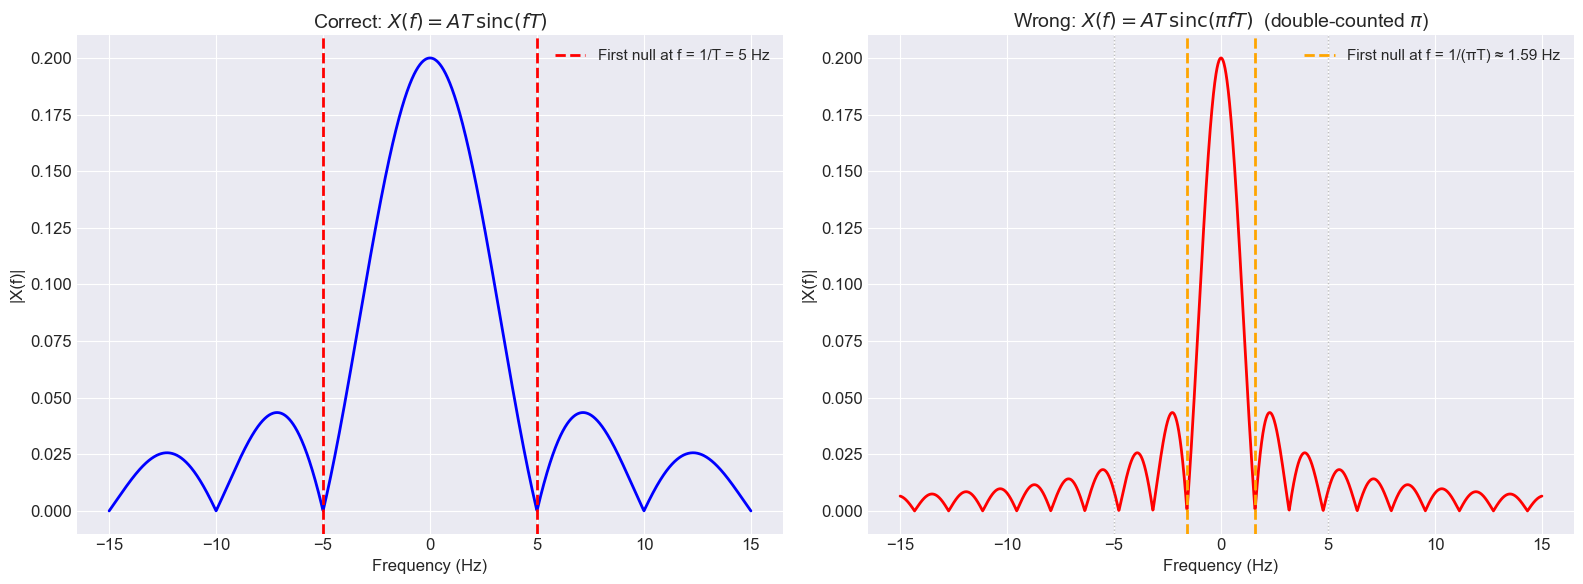

Pulse width T = 0.2 s

Correct (normalized sinc):
  X(f) = AT · sinc(fT)
  First null at f = 1/T = 5.0 Hz  ✓

Wrong (double-counted π):
  X(f) = AT · sinc(πfT)   ← extra π in argument
  First null at f = 1/(πT) = 1.59 Hz  ✗
  This predicts a narrower main lobe by a factor of π!


In [3]:
# Demonstrate with the rect/sinc Fourier transform pair

T = 0.2  # Pulse width (seconds)
A = 1.0  # Amplitude
f = np.linspace(-15, 15, 2000)

# Correct: X(f) = A*T * sinc(f*T)  using normalized sinc
X_correct = A * T * np.sinc(f * T)

# WRONG: what happens if you use sinc(pi*f*T) thinking sinc = sin(x)/x
# This is equivalent to sinc_norm(f*T/1) with an extra pi stuck in,
# i.e., np.sinc(f*T) already has the pi built in. 
# The mistake: writing sinc(pi*f*T) with normalized sinc = double-counting pi
X_wrong = A * T * np.sinc(np.pi * f * T)  # WRONG — zeros at f = 1/(pi*T)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correct
ax = axes[0]
ax.plot(f, np.abs(X_correct), 'b-', linewidth=2)
ax.axvline(x=1/T, color='red', linestyle='--', linewidth=2, 
           label=f'First null at f = 1/T = {1/T:.0f} Hz')
ax.axvline(x=-1/T, color='red', linestyle='--', linewidth=2)
ax.set_title(r'Correct: $X(f) = AT\,\mathrm{sinc}(fT)$', fontsize=14)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('|X(f)|')
ax.legend(fontsize=11)

# Wrong
ax = axes[1]
ax.plot(f, np.abs(X_wrong), 'r-', linewidth=2)
ax.axvline(x=1/(np.pi*T), color='orange', linestyle='--', linewidth=2,
           label=f'First null at f = 1/(πT) ≈ {1/(np.pi*T):.2f} Hz')
ax.axvline(x=-1/(np.pi*T), color='orange', linestyle='--', linewidth=2)
ax.axvline(x=1/T, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(x=-1/T, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.set_title(r'Wrong: $X(f) = AT\,\mathrm{sinc}(\pi fT)$  (double-counted $\pi$)', fontsize=14)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('|X(f)|')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"Pulse width T = {T} s")
print(f"")
print(f"Correct (normalized sinc):")
print(f"  X(f) = AT · sinc(fT)")
print(f"  First null at f = 1/T = {1/T:.1f} Hz  ✓")
print(f"")
print(f"Wrong (double-counted π):")
print(f"  X(f) = AT · sinc(πfT)   ← extra π in argument")
print(f"  First null at f = 1/(πT) = {1/(np.pi*T):.2f} Hz  ✗")
print(f"  This predicts a narrower main lobe by a factor of π!")

## NumPy and MATLAB Both Use the Normalized Definition

This is important for coding:

- **NumPy:** `np.sinc(x)` computes $\sin(\pi x)/(\pi x)$
- **MATLAB:** `sinc(x)` computes $\sin(\pi x)/(\pi x)$

So to compute $X(f) = AT \cdot \text{sinc}(fT)$, you simply write:

```python
X = A * T * np.sinc(f * T)   # correct
```

Do **not** write `np.sinc(np.pi * f * T)` — that would double-count the $\pi$.

In [4]:
# Verify np.sinc uses the normalized definition
print("Verifying np.sinc definition:")
print("=" * 45)

test_values = [0, 0.5, 1, 1.5, 2, 3]
print(f"{'x':>6}  {'np.sinc(x)':>12}  {'sin(πx)/(πx)':>14}  {'Match?':>8}")
print("-" * 45)
for x in test_values:
    np_result = np.sinc(x)
    if x == 0:
        manual = 1.0
    else:
        manual = np.sin(np.pi * x) / (np.pi * x)
    match = "✓" if np.isclose(np_result, manual) else "✗"
    print(f"{x:>6.1f}  {np_result:>12.6f}  {manual:>14.6f}  {match:>8}")

print("\nnp.sinc(1) = 0  because sin(π·1)/(π·1) = sin(π)/π = 0")
print("np.sinc(0) = 1  by L'Hôpital's rule (limit definition)")

Verifying np.sinc definition:
     x    np.sinc(x)    sin(πx)/(πx)    Match?
---------------------------------------------
   0.0      1.000000        1.000000         ✓
   0.5      0.636620        0.636620         ✓
   1.0      0.000000        0.000000         ✓
   1.5     -0.212207       -0.212207         ✓
   2.0     -0.000000       -0.000000         ✓
   3.0      0.000000        0.000000         ✓

np.sinc(1) = 0  because sin(π·1)/(π·1) = sin(π)/π = 0
np.sinc(0) = 1  by L'Hôpital's rule (limit definition)


## Overlay Comparison

Let's plot both definitions on the same axes so the difference is unmistakable.

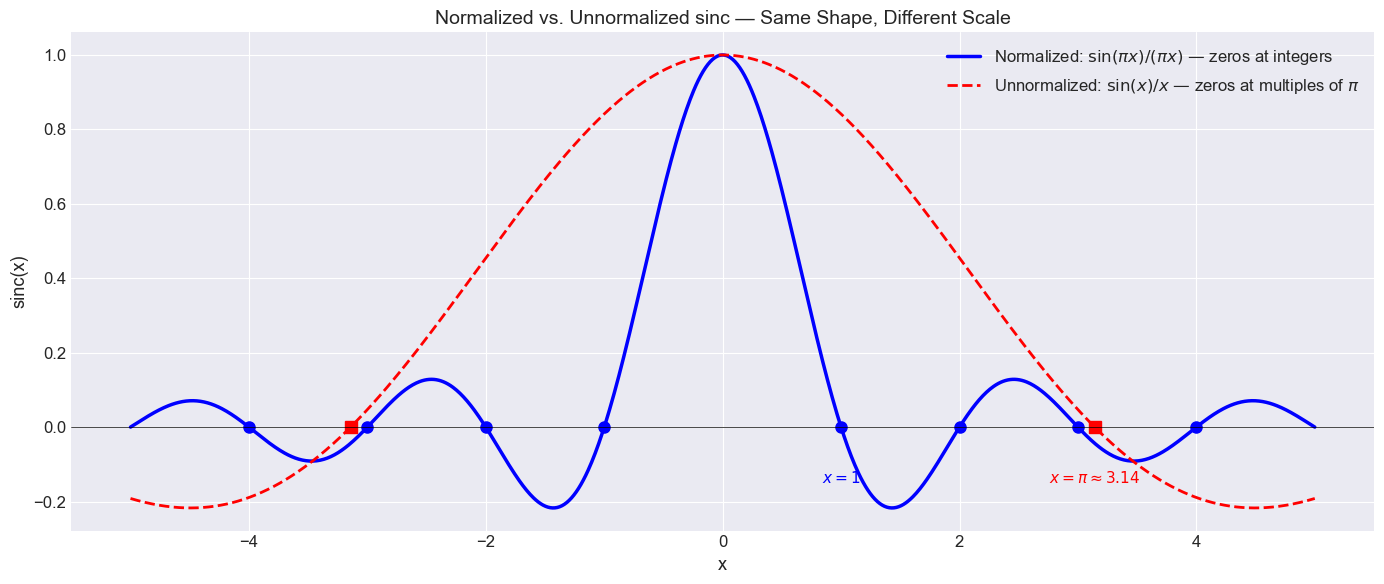

The two functions have the same shape but are stretched
horizontally by a factor of π ≈ 3.1416.

Normalized first zero:   x = 1
Unnormalized first zero: x = π ≈ 3.1416

The unnormalized sinc is wider and decays more slowly
when plotted on the same x-axis.


In [5]:
x = np.linspace(-5, 5, 1000)

sinc_norm = np.sinc(x)                                          # sin(πx)/(πx)
sinc_unnorm = np.where(x == 0, 1.0, np.sin(x) / x)            # sin(x)/x

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x, sinc_norm, 'b-', linewidth=2.5, 
        label=r'Normalized: $\sin(\pi x)/(\pi x)$ — zeros at integers')
ax.plot(x, sinc_unnorm, 'r--', linewidth=2,
        label=r'Unnormalized: $\sin(x)/x$ — zeros at multiples of $\pi$')

# Mark zeros
int_zeros = np.array([-4, -3, -2, -1, 1, 2, 3, 4])
ax.plot(int_zeros, np.zeros_like(int_zeros), 'bo', markersize=8)

pi_zeros = np.array([-np.pi, np.pi])
ax.plot(pi_zeros, np.zeros_like(pi_zeros), 'rs', markersize=8)

# Annotate key zero locations
ax.annotate(r'$x = 1$', xy=(1, 0), xytext=(1, -0.15),
            ha='center', fontsize=11, color='blue', fontweight='bold')
ax.annotate(r'$x = \pi \approx 3.14$', xy=(np.pi, 0), xytext=(np.pi, -0.15),
            ha='center', fontsize=11, color='red', fontweight='bold')

ax.axhline(y=0, color='k', linewidth=0.5)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('sinc(x)', fontsize=13)
ax.set_title('Normalized vs. Unnormalized sinc — Same Shape, Different Scale', fontsize=14)
ax.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

print("The two functions have the same shape but are stretched")
print(f"horizontally by a factor of π ≈ {np.pi:.4f}.")
print(f"")
print(f"Normalized first zero:   x = 1")
print(f"Unnormalized first zero: x = π ≈ {np.pi:.4f}")
print(f"")
print(f"The unnormalized sinc is wider and decays more slowly")
print(f"when plotted on the same x-axis.")

## Summary

| Property | Normalized $\text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}$ | Unnormalized $\frac{\sin(x)}{x}$ |
|----------|:---:|:---:|
| Value at origin | 1 | 1 |
| First zero | $x = \pm 1$ | $x = \pm \pi$ |
| Integral over $\mathbb{R}$ | 1 | $\pi$ |
| Used by NumPy/MATLAB | Yes | No |
| Used by Haykin & Moher | Yes (Eq. 2.9) | No |

### Rules for this course

1. **sinc always means the normalized definition:** $\text{sinc}(x) = \sin(\pi x)/(\pi x)$
2. **Fourier pair:** $\text{rect}(t/T) \longleftrightarrow T \cdot \text{sinc}(fT)$, first null at $f = 1/T$
3. **In Python:** `np.sinc(x)` already computes the normalized sinc — do not add extra $\pi$ factors

When reading other references, always check which convention they use. If you see $\text{sinc}(\pi f T)$ in a formula, that author is likely using the unnormalized $\sin(x)/x$ convention.